## Level 3 – Sales Analysis
**Objective:** Analyze sales performance by product category, outlet type, and identify top-performing products using Item_MRP as the sales proxy.

In [4]:
### 1. Import Libraries & Load Cleaned Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Big_Mart_Sales_Cleaned.csv')
print(f' Cleaned dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

 Cleaned dataset loaded: 5681 rows × 12 columns


In [6]:
### 2.  Overall Sales Performance (KPIs)

total_sales     = df['Item_MRP'].sum()
avg_mrp         = df['Item_MRP'].mean()
total_items     = df['Item_Identifier'].nunique()
total_outlets   = df['Outlet_Identifier'].nunique()
total_records   = len(df)

print('=' * 45)
print('        KEY PERFORMANCE INDICATORS')
print('=' * 45)
print(f'   Total MRP (Sales Proxy): ₹{total_sales:,.2f}')
print(f'   Average Item MRP       : ₹{avg_mrp:,.2f}')
print(f'   Unique Products        : {total_items}')
print(f'   Total Outlets           : {total_outlets}')
print(f'   Total Transactions      : {total_records:,}')
print('=' * 45)

        KEY PERFORMANCE INDICATORS
   Total MRP (Sales Proxy): ₹801,153.23
   Average Item MRP       : ₹141.02
   Unique Products        : 1543
   Total Outlets           : 10
   Total Transactions      : 5,681


In [7]:
### 3. Sales by Product Category (Item_Type)

sales_by_category = df.groupby('Item_Type')['Item_MRP'].agg(
    Total_Sales='sum',
    Avg_MRP='mean',
    Item_Count='count'
).sort_values('Total_Sales', ascending=False).round(2)

sales_by_category['Sales_Share_%'] = (sales_by_category['Total_Sales'] / total_sales * 100).round(2)

print('Sales by Product Category:')
print(sales_by_category.to_string())

Sales by Product Category:
                       Total_Sales  Avg_MRP  Item_Count  Sales_Share_%
Item_Type                                                             
Snack Foods              115875.62   146.86         789          14.46
Fruits and Vegetables    112360.41   143.87         781          14.02
Household                 94267.72   147.76         638          11.77
Frozen Foods              76043.81   133.41         570           9.49
Dairy                     65977.95   145.33         454           8.24
Canned                    59558.32   136.92         435           7.43
Baking Goods              56524.84   129.05         438           7.06
Health and Hygiene        46180.73   136.63         338           5.76
Meat                      43804.27   140.85         311           5.47
Soft Drinks               39788.91   141.60         281           4.97
Breads                    23439.17   142.06         165           2.93
Hard Drinks               20366.13   137.61       

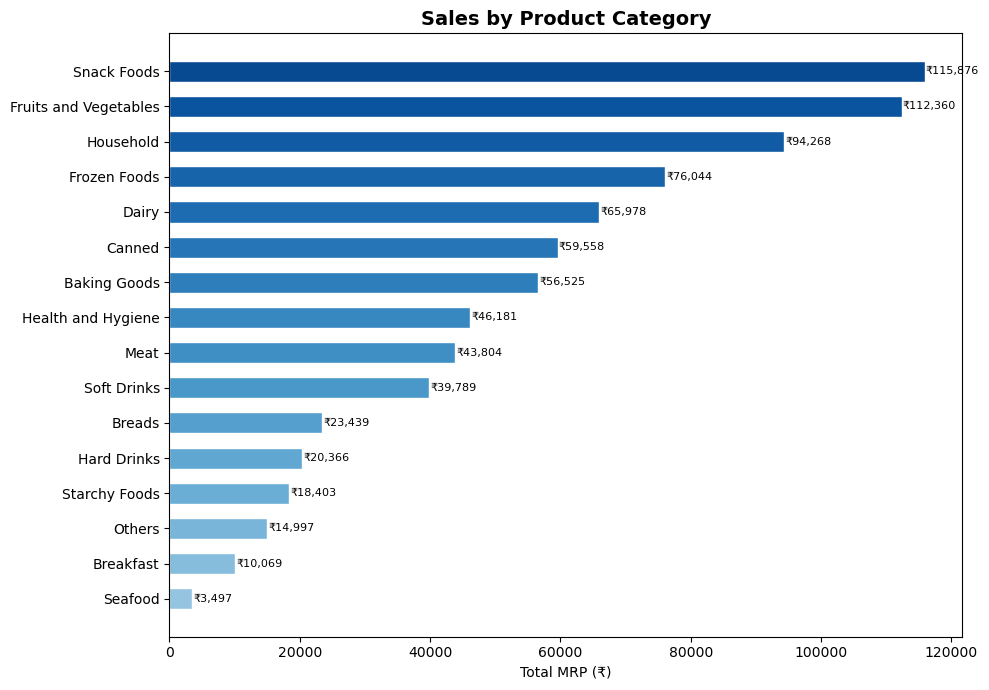

In [8]:
# Bar chart — Sales by Category

cat_sales = df.groupby('Item_Type')['Item_MRP'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_sales)))
bars = plt.barh(cat_sales.index, cat_sales.values, color=colors, edgecolor='white', height=0.6)

for bar in bars:
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():,.0f}', va='center', fontsize=8)

plt.title('Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Total MRP (₹)')
plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
### 4. Sales by Outlet Type

sales_by_outlet = df.groupby('Outlet_Type')['Item_MRP'].agg(
    Total_Sales='sum',
    Avg_MRP='mean',
    Item_Count='count'
).sort_values('Total_Sales', ascending=False).round(2)

sales_by_outlet['Sales_Share_%'] = (sales_by_outlet['Total_Sales'] / total_sales * 100).round(2)

print(' Sales by Outlet Type:')
print(sales_by_outlet.to_string())

 Sales by Outlet Type:
                   Total_Sales  Avg_MRP  Item_Count  Sales_Share_%
Outlet_Type                                                       
Supermarket Type1    523024.22   140.71        3717          65.28
Grocery Store        102495.82   141.96         722          12.79
Supermarket Type3     89123.60   142.83         624          11.12
Supermarket Type2     86509.59   139.98         618          10.80


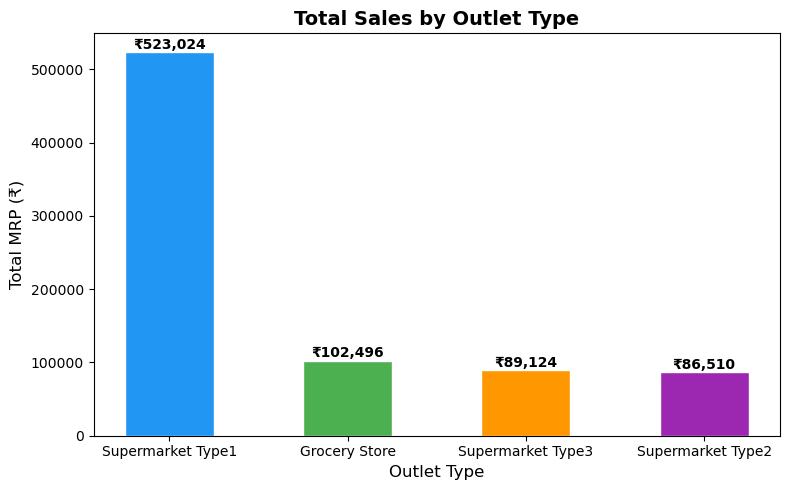

In [12]:
# Bar chart — Sales by Outlet Type

plt.figure(figsize=(8, 5))
outlet_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = plt.bar(sales_by_outlet.index, sales_by_outlet['Total_Sales'], 
               color=outlet_colors[:len(sales_by_outlet)], edgecolor='white', width=0.5)
plt.title('Total Sales by Outlet Type', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Type', fontsize=12)
plt.ylabel('Total MRP (₹)', fontsize=12)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sales_by_outlet.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
### 5. Sales by Outlet Size & Location Type

# By Outlet Size
sales_by_size = df.groupby('Outlet_Size')['Item_MRP'].sum().sort_values(ascending=False).round(2)
print(' Sales by Outlet Size:')
print(sales_by_size)

print()

# By Location Type
sales_by_location = df.groupby('Outlet_Location_Type')['Item_MRP'].sum().sort_values(ascending=False).round(2)
print(' Sales by Location Type (City Tier):')
print(sales_by_location)

 Sales by Outlet Size:
Outlet_Size
Small     449830.42
Medium    263959.35
High       87363.46
Name: Item_MRP, dtype: float64

 Sales by Location Type (City Tier):
Outlet_Location_Type
Tier 3    315437.90
Tier 2    261173.99
Tier 1    224541.34
Name: Item_MRP, dtype: float64


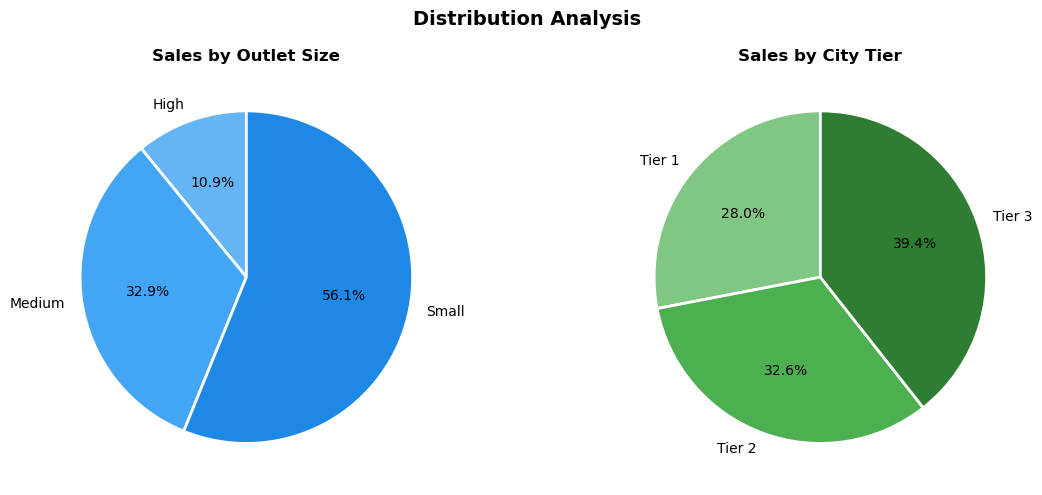

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Outlet Size
size_data = df.groupby('Outlet_Size')['Item_MRP'].sum()
axes[0].pie(size_data.values, labels=size_data.index, autopct='%1.1f%%',
            colors=['#64B5F6', '#42A5F5', '#1E88E5'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Sales by Outlet Size', fontweight='bold')

# City Tier
loc_data = df.groupby('Outlet_Location_Type')['Item_MRP'].sum()
axes[1].pie(loc_data.values, labels=loc_data.index, autopct='%1.1f%%',
            colors=['#81C784', '#4CAF50', '#2E7D32'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sales by City Tier', fontweight='bold')

plt.suptitle('Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
### 6. Top 10 Performing Products by MRP

top_products = df.groupby('Item_Identifier')['Item_MRP'].mean().sort_values(ascending=False).head(10).round(2)

print('🏆 Top 10 Products by Average MRP:')
print(top_products.to_string())

🏆 Top 10 Products by Average MRP:
Item_Identifier
FDR25    265.92
NCS06    264.79
NCM05    264.67
FDK51    264.59
FDI15    264.59
FDY14    264.55
FDS13    264.26
FDB15    264.16
FDL58    264.16
FDV49    264.12


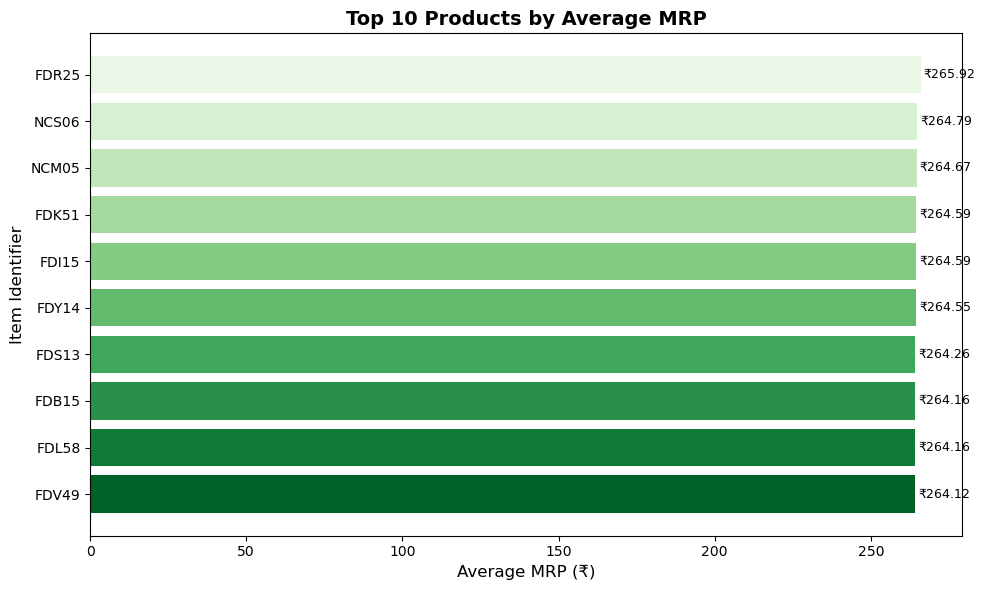

In [33]:
# Horizontal bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(top_products.index[::-1], top_products.values[::-1],
                color=sns.color_palette('Greens_r', 10))
plt.title('Top 10 Products by Average MRP', fontsize=14, fontweight='bold')
plt.xlabel('Average MRP (₹)', fontsize=12)
plt.ylabel('Item Identifier', fontsize=12)

for bar in bars:
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

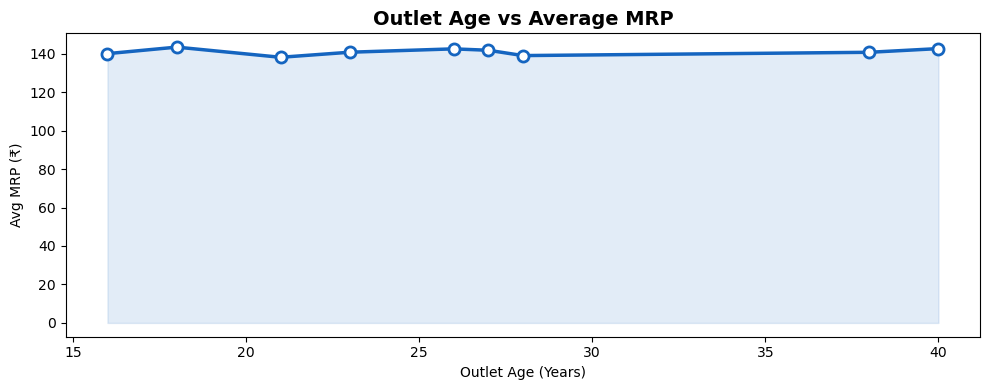

In [18]:
### 7. Outlet Age Trend (Line chart)

age_data = df.groupby('Outlet_Age')['Item_MRP'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(age_data['Outlet_Age'], age_data['Item_MRP'],
         marker='o', linewidth=2.5, color='#1565C0',
         markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.fill_between(age_data['Outlet_Age'], age_data['Item_MRP'], alpha=0.12, color='#1565C0')
plt.title('Outlet Age vs Average MRP', fontsize=14, fontweight='bold')
plt.xlabel('Outlet Age (Years)')
plt.ylabel('Avg MRP (₹)')
plt.tight_layout()
plt.savefig('outlet_age_trend.png', dpi=150, bbox_inches='tight')
plt.show()